# Exploratory Data Analysis (EDA) - Requirements Classification
This notebook demonstrates how to use the preprocessing functions from `src.preprocessing` and performs basic statistics on **both** datasets (PROMISE and DCAI24) sequentially.

In [1]:
import sys
import os
# Add the root directory to the system path so Python can import the 'src' folder
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import load_and_preprocess_data

# A helper function to plot labels dynamically for any dataset
def plot_label_distribution(df, dataset_name):
    ignore_cols = ['ProjectID', 'RequirementText', 'Requirement', 'CleanedText', 'Dataset_Name']
    label_cols = [c for c in df.columns if c not in ignore_cols]
    
    is_categorical = df[label_cols].select_dtypes(include=['object', 'string']).shape[1] > 0
    
    if not is_categorical:
        label_counts = df[label_cols].sum().sort_values(ascending=False)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")
        plt.title(f'Label Distribution - {dataset_name}', fontsize=14)
        plt.xlabel('Number of Requirements')
        plt.ylabel('Label Name')
        plt.show()
    else:
        for col in label_cols:
            plt.figure(figsize=(8, 4))
            counts = df[col].value_counts()
            sns.barplot(x=counts.values, y=counts.index, palette="mako")
            plt.title(f'Label Distribution for column: {col} - {dataset_name}', fontsize=14)
            plt.xlabel('Count')
            plt.ylabel(col)
            plt.show()

[nltk_data] Downloading package wordnet to C:\Users\ThinkPad
[nltk_data]     X1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 1. PROMISE Dataset Analysis

Reading data from ../data/raw/PROMISE-relabeled-NICE.csv...
Cleaning text data...
Preprocessing completed!

--- PROMISE Data Sample ---


,RequirementText,CleanedText
0,'The system shall refresh the display every 60...,system shall refresh display every second
1,'The application shall match the color of the ...,application shall match color schema set forth...
2,'If projected the data must be readable. On a ...,projected data must readable x projection scre...
3,'The product shall be available during normal ...,product shall available normal business hour l...
4,'If projected the data must be understandable....,projected data must understandable x projectio...


C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_15276\971392601.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")


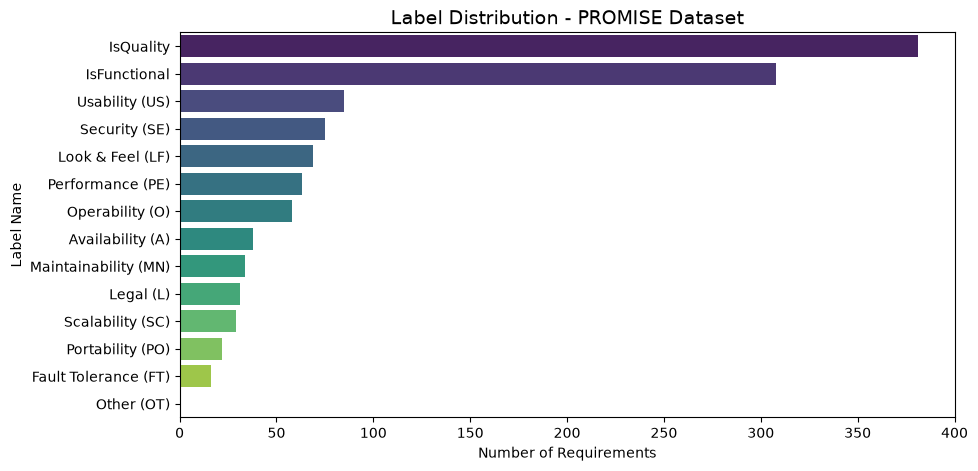

In [ ]:
from IPython import display
promise_path = '../data/raw/PROMISE-relabeled-NICE.csv'
df_promise = load_and_preprocess_data(promise_path)

print("\n--- PROMISE Data Sample ---")
display(df_promise[['RequirementText', 'CleanedText']].head())

# Plot PROMISE labels
plot_label_distribution(df_promise, "PROMISE Dataset")

### 2. DCAI24 Dataset Analysis

Reading data from ../data/raw/dcai24_src_dataset.xlsx...
Cleaning text data...
Preprocessing completed!

--- DCAI24 Data Sample ---


,Requirement,CleanedText
0,The system must authenticate users prior to ac...,system must authenticate user prior accessing ...
1,The system must prevent access to applications...,system must prevent access application data no...
2,The system should provide the ability to imple...,system provide ability implement chain trust a...
3,The system must authenticate users using at le...,system must authenticate user using least one ...
4,The system must provide the ability to create ...,system must provide ability create update set ...


C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_15276\971392601.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="mako")


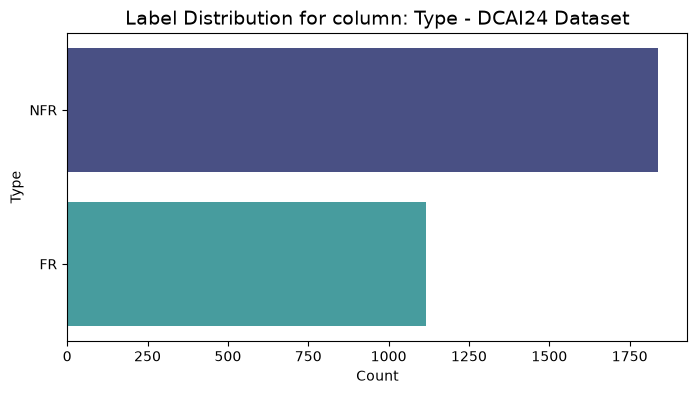

C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_15276\971392601.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="mako")


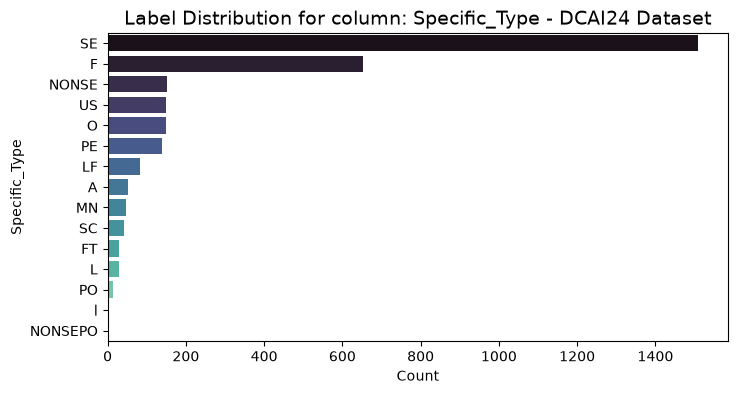

C:\Users\ThinkPad X1\AppData\Local\Temp\ipykernel_15276\971392601.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="mako")


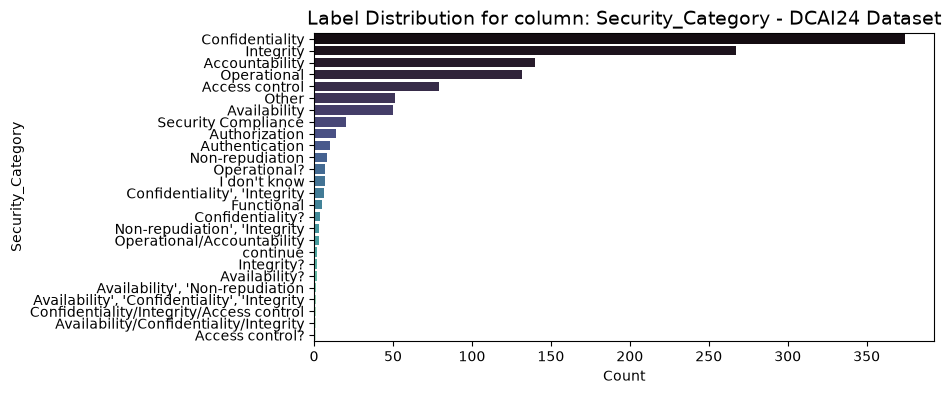

In [3]:
dcai24_path = '../data/raw/dcai24_src_dataset.xlsx'
df_dcai24 = load_and_preprocess_data(dcai24_path)

print("\n--- DCAI24 Data Sample ---")
display(df_dcai24[['Requirement', 'CleanedText']].head())

# Plot DCAI24 labels
plot_label_distribution(df_dcai24, "DCAI24 Dataset")

# Exploratory Data Analysis (EDA) for All Four Datasets

This notebook loads the four raw data sources, shows basic statistics, class distribution, missing values, and some visualisations.


In [15]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


## 1. Load the datasets


In [16]:
# Correct relative path from notebooks/ folder
raw_path = '../data/raw/'
ears_path = raw_path + 'EARS Functional Requirements Complete Dataset.xlsx'
promise_path = raw_path + 'PROMISE-relabeled-NICE.csv'
dcai_path = raw_path + 'dcai24_src_dataset.xlsx'
exp_path = raw_path + 'promise_exp.csv'

ears = pd.read_excel(ears_path)
promise = pd.read_csv(promise_path)
dcai = pd.read_excel(dcai_path)
exp = pd.read_csv(exp_path)

datasets = {'EARS': ears, 'PROMISE': promise, 'DCAI24': dcai, 'PROMISE_EXP': exp}
for name, df in datasets.items():
    print(f'--- {name} ---')
    print('Shape:', df.shape)
    print('Columns:', df.columns.tolist())
    print('Head:', df.head(2).to_dict(orient='list'))
    print('Missing values:', df.isnull().sum().sum())
    print('')


--- EARS ---
Shape: (9677, 6)
Columns: ['Projects', 'Raw Requirements', 'Requiremnet Name', 'EARS Type', 'EARS Requirement', 'Unnamed: 5']
Head: {'Projects': ['PR-01', 'PR-01'], 'Raw Requirements': ['The Game must be developed using the Unity Game Engine', 'The Game must be programmed using the C# language and its libraries compatible with the Unity Engine'], 'Requiremnet Name': ['Game Engine', 'Language'], 'EARS Type': ['ubiquitous', 'ubiquitous'], 'EARS Requirement': ['The game shall be developed using unity game engine', 'The game shall be written in C# and use Unity Engine-compatible libraries.'], 'Unnamed: 5': [nan, nan]}
Missing values: 10696

--- PROMISE ---
Shape: (622, 16)
Columns: ['ProjectID', 'RequirementText', 'IsFunctional', 'IsQuality', 'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 'Security (SE)', 'Usability (US)', 'Other (OT)']
Head: {'P

## 2. Class distribution (FR vs NFR)
We assume the label column is named `label` or `class`. Adjust if needed.


EARS: No obvious label column
PROMISE: No obvious label column
DCAI24: No obvious label column
PROMISE_EXP label distribution:
class
F     444
SE    125
US     85
O      77
PE     67
LF     49
A      31
MN     24
SC     22
FT     18
L      15
PO     12
Name: count, dtype: int64


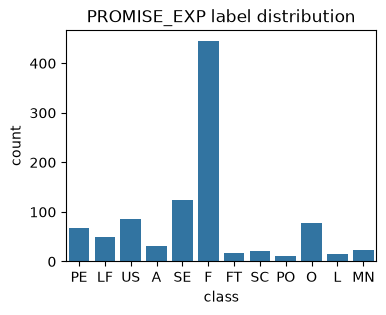

In [17]:
def get_label_col(df):
    for col in ['label', 'class', 'Category', 'Requirement Type']:
        if col in df.columns:
            return col
    return None

for name, df in datasets.items():
    label_col = get_label_col(df)
    if label_col is None:
        print(f'{name}: No obvious label column')
        continue
    print(f'{name} label distribution:')
    print(df[label_col].value_counts())
    plt.figure(figsize=(4,3))
    sns.countplot(x=df[label_col])
    plt.title(f'{name} label distribution')
    plt.show()


## 3. Text length statistics (if a `text` column exists)


In [18]:
for name, df in datasets.items():
    text_col = None
    for col in ['text', 'requirement', 'sentence', 'description']:
        if col in df.columns:
            text_col = col
            break
    if text_col is None:
        print(f'{name}: no text column')
        continue
    lengths = df[text_col].astype(str).apply(len)
    print(f'{name} text length stats:')
    print(lengths.describe())
    plt.figure(figsize=(5,3))
    sns.histplot(lengths, bins=30, kde=True)
    plt.title(f'{name} text length distribution')
    plt.xlabel('Character count')
    plt.show()


EARS: no text column
PROMISE: no text column
DCAI24: no text column
PROMISE_EXP: no text column


## 4. Basic numeric feature inspection (if any)


EARS: no numeric columns
PROMISE numeric summary:
        ProjectID  IsFunctional   IsQuality  Availability (A)  \
count  622.000000    622.000000  622.000000        622.000000   
mean     6.535370      0.495177    0.612540          0.061093   
std      3.509527      0.500379    0.487562          0.239694   
min      1.000000      0.000000    0.000000          0.000000   
25%      4.000000      0.000000    0.000000          0.000000   
50%      6.000000      0.000000    1.000000          0.000000   
75%      9.000000      1.000000    1.000000          0.000000   
max     15.000000      1.000000    1.000000          1.000000   

       Fault Tolerance (FT)   Legal (L)  Look & Feel (LF)  \
count            622.000000  622.000000        622.000000   
mean               0.025723    0.049839          0.110932   
std                0.158437    0.217788          0.314301   
min                0.000000    0.000000          0.000000   
25%                0.000000    0.000000          0.000000  

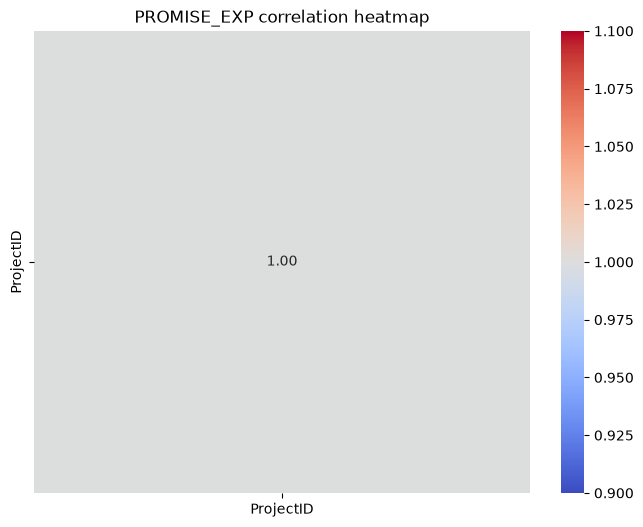

In [19]:
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        print(f'{name}: no numeric columns')
        continue
    print(f'{name} numeric summary:')
    print(df[numeric_cols].describe())
    if len(numeric_cols) <= 10:
        plt.figure(figsize=(8,6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
        plt.title(f'{name} correlation heatmap')
        plt.show()


## 5. Save a quick summary CSV
We combine a few high‑level stats into one CSV for later reference.


In [20]:
summary_rows = []
for name, df in datasets.items():
    label_col = get_label_col(df)
    label_counts = df[label_col].value_counts().to_dict() if label_col else {}
    summary_rows.append({
        'dataset': name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'missing': df.isnull().sum().sum(),
        **label_counts
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('data/processed/dataset_summary.csv', index=False)
print('Saved summary to data/processed/dataset_summary.csv')


OSError: Cannot save file into a non-existent directory: 'data\processed'